# Mixture of Gaussians (Linear Mean)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable
from collections import deque
import torch

In [2]:
def RGD(
    f_hat: Callable,
    D_theta: Callable,
    loss: Callable,
    theta_0: torch.Tensor,
    proj_theta: Callable = lambda x: x,
    n: int = 1000,
    eta: float = 0.1,
    tol: float = 1e-5,
    max_iter: int = 100
):

    all_thetas = [theta_0.clone().detach().squeeze()]
    
    theta_t = theta_0
    converged = False
    t = 0
    
    while not converged and t < max_iter:
        # Draw n samples from D(theta)
        z = D_theta(theta_t, n)
        
        # Compute gradient of loss (dL1)
        theta_t.requires_grad_(True)
        theta_t.grad = None 
        l_t = loss(z, theta_t).mean(dim=-1)
        l_t.backward()
        dL1 = theta_t.grad
        
        with torch.no_grad():
            theta_t = proj_theta(theta_t - eta * dL1)
        
        all_thetas.append(theta_t.detach().squeeze())
        
        # Check convergence
        if dL1.norm() < tol: 
            converged = True
        
        t += 1
    
    return theta_t, all_thetas

In [3]:
def PerfGD(
    f_hat: Callable,
    grad2_est: Callable,
    D_theta: Callable,
    loss: Callable,
    theta_0: torch.Tensor,
    proj_theta: Callable = lambda x: x,
    n: int = 1000,
    eta: float = 0.1,
    warmup: int = 1,
    tol: float = 1e-5,
    max_iter: int = 100
):
    
    all_thetas = [theta_0.clone().detach().squeeze()]

    # Use unlimited history instead of fixed H
    theta_history = []
    f_history = []

    # Take only 1 step of RGD for initialization
    theta_t = theta_0
    z = D_theta(theta_t, n) # Draw n samples from D(theta)
    f_t = f_hat(z)  # Estimate for f(theta)

    theta_history.append(theta_t.detach())
    f_history.append(f_t.detach())

    # One gradient descent step on Loss_1 loss
    theta_t.requires_grad_(True)
    theta_t.grad = None 
    l_t = loss(z, theta_t).mean(dim=-1)
    l_t.backward()
    dL1 = theta_t.grad

    with torch.no_grad():
        theta_t = proj_theta(theta_t - eta * dL1)

    all_thetas.append(theta_t.detach().squeeze())

    # Now run with full gradient update using entire history
    converged = False
    t = 1
    while not converged:

        z = D_theta(theta_t, n) # Draw n samples from D(theta) (d x n)
        f_t = f_hat(z) # (d,)
        
        theta_history.append(theta_t.detach())
        f_history.append(f_t.detach())

        theta_t.requires_grad_(True)
        theta_t.grad = None 
        l_t = loss(z, theta_t).mean(dim=-1)
        l_t.backward()
        dL1 = theta_t.grad
        
        # Use entire history (not just last H steps)
        if len(theta_history) >= 2:  # Need at least 2 points for gradient estimation
            Theta_full = torch.stack([th for th in theta_history], dim=1)   # (p, t+1)
            F_full = torch.stack([fh for fh in f_history], dim=1)   # (q, t+1)
            
            Theta = Theta_full[:, :-1]                                      # (p, t) -> 0 : t-1
            F = F_full[:, :-1]
            oneH = torch.ones(1, Theta.shape[1], device=Theta.device)

            delta_theta = Theta - theta_t.unsqueeze(1) @ oneH          # (p, t)
            delta_f = F - f_t.unsqueeze(1) @ oneH          # (q, t)

            df_d_theta = delta_f @ torch.linalg.pinv(delta_theta) # (p x q)

            dL2 = grad2_est(z, f_t, theta_t, df_d_theta)
        else:
            dL2 = torch.zeros_like(dL1)  # No performative correction if not enough history

        with torch.no_grad():
            theta_t = proj_theta(theta_t - eta * (dL1 + dL2))

        all_thetas.append(theta_t.detach().squeeze())
        
        if (dL1 + dL2).norm() < tol: 
            break # Converged
        
        t += 1
        if t > max_iter: 
            break # Max iterations
    
    return theta_t, all_thetas

In [4]:
def run_experiment():
    # Mixture of Gaussians example with 5 trials
    # Parameters from PerfGD paper Appendix E.1
    gamma = 0.5
    sigma1_sq = 1.0
    sigma2_sq = 0.25
    a1_0 = -0.5
    a1_1 = 1.0
    a2_0 = 1.0
    a2_1 = -0.3

    # Component means as functions of theta
    mu1 = lambda theta: a1_0 + a1_1 * theta  # First component mean
    mu2 = lambda theta: a2_0 + a2_1 * theta  # Second component mean

    # Define the mixture distribution
    def D_theta_mixture(theta, n):
        # Sample from mixture of Gaussians
        n1 = int(gamma * n)
        n2 = n - n1
        
        # Sample from first component
        z1 = torch.normal(mu1(theta).squeeze(), torch.sqrt(torch.tensor(sigma1_sq)), size=(1, n1))
        # Sample from second component  
        z2 = torch.normal(mu2(theta).squeeze(), torch.sqrt(torch.tensor(sigma2_sq)), size=(1, n2))
        
        # Combine samples
        z = torch.cat([z1, z2], dim=1)
        return z

    # Estimator function (sample mean)
    f_hat_mixture = lambda z: z.mean(dim=1)

    # Loss function
    loss_mixture = lambda z, theta: z * theta

    # Gradient estimation function for PerfGD
    def grad2_est_mixture(z, f, theta, df_d_theta):
        if z.ndim == 1: z = z.unsqueeze(0)
        if f.ndim == 1: f = f.unsqueeze(0)
        # For mixture, we need to account for the mixture structure
        sigma_mixture = torch.tensor([[sigma1_sq]])  # Use first component variance
        return torch.mean(loss_mixture(z, theta) * (df_d_theta.T @ torch.linalg.inv(sigma_mixture) @ (z - f)), dim=-1)

    # Projection function
    proj_theta_mixture = lambda x: x.clamp(min=-1.0, max=1.0)

    # Run 5 trials
    num_trials = 5
    all_rgd_trajectories = []
    all_perfgd_trajectories = []
    rgd_final_thetas = []
    perfgd_final_thetas = []

    for trial in range(num_trials):        
        # Run RGD
        theta_rgd_mix, all_theta_rgd_mix = RGD(
            f_hat_mixture,
            D_theta_mixture,
            loss_mixture,
            theta_0=torch.tensor([0.0]),
            proj_theta=proj_theta_mixture,
            n=1000,
            eta=0.1,  # Use proper learning rate
            tol=1e-5,
            max_iter=100
        )
        
        # Run PerfGD
        theta_perfgd_mix, all_theta_perfgd_mix = PerfGD(
            f_hat_mixture,
            grad2_est_mixture,
            D_theta_mixture,
            loss_mixture,
            theta_0=torch.tensor([0.0]),
            proj_theta=proj_theta_mixture,
            n=1000,
            eta=0.1,  # Use proper learning rate
            warmup=1,
            tol=1e-5,
            max_iter=100
        )
        
        # Store results
        all_rgd_trajectories.append(all_theta_rgd_mix)
        all_perfgd_trajectories.append(all_theta_perfgd_mix)
        rgd_final_thetas.append(theta_rgd_mix.item())
        perfgd_final_thetas.append(theta_perfgd_mix.item())

    # Compute average trajectories
    max_length = max(len(traj) for traj in all_rgd_trajectories + all_perfgd_trajectories)
    avg_rgd_trajectory = []
    avg_perfgd_trajectory = []

    for i in range(max_length):
        rgd_values = []
        perfgd_values = []
        
        for traj in all_rgd_trajectories:
            if i < len(traj):
                rgd_values.append(traj[i].item())
        
        for traj in all_perfgd_trajectories:
            if i < len(traj):
                perfgd_values.append(traj[i].item())
        
        if rgd_values:
            avg_rgd_trajectory.append(np.mean(rgd_values))
        if perfgd_values:
            avg_perfgd_trajectory.append(np.mean(perfgd_values))

    # Plot results
    plt.figure(figsize=(12, 8))

    # Plot average trajectories
    plt.plot(avg_rgd_trajectory, label='RGD (Average)', linewidth=3, color='purple')
    plt.plot(avg_perfgd_trajectory, label='PerfGD (Average)', linewidth=3, color='orange')

    # Plot individual trajectories with transparency
    for i, traj in enumerate(all_rgd_trajectories):
        if len(traj) > 0:
            plt.plot(torch.stack(traj), alpha=0.3, color='purple', linewidth=1)

    for i, traj in enumerate(all_perfgd_trajectories):
        if len(traj) > 0:
            plt.plot(torch.stack(traj), alpha=0.3, color='orange', linewidth=1)

    # Add theoretical solutions from paper Appendix E.1
    theta_opt = -0.5 * (gamma * a1_0 + (1 - gamma) * a2_0) / (gamma * a1_1 + (1 - gamma) * a2_1)
    theta_stab = -(gamma * a1_0 + (1 - gamma) * a2_0) / (gamma * a1_1 + (1 - gamma) * a2_1)

    plt.axhline(y=theta_opt, color='r', linestyle='dashed', linewidth=2, label='θOPT (Paper)')
    plt.axhline(y=theta_stab, color='b', linestyle='dashed', linewidth=2, label='θSTAB (Paper)')

    plt.legend(fontsize=12)
    plt.title('RGD vs PerfGD on Mixture of Gaussians (5 Trials Average)', fontsize=14)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel(r'$\theta$', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

    # Print summary statistics
    print(f"\nSummary Statistics ({num_trials} trials):")
    print(f"RGD final theta - Mean: {np.mean(rgd_final_thetas):.6f}, Std: {np.std(rgd_final_thetas):.6f}")
    print(f"PerfGD final theta - Mean: {np.mean(perfgd_final_thetas):.6f}, Std: {np.std(perfgd_final_thetas):.6f}")
    print(f"Theoretical θOPT: {theta_opt:.6f}")
    print(f"Theoretical θSTAB: {theta_stab:.6f}")

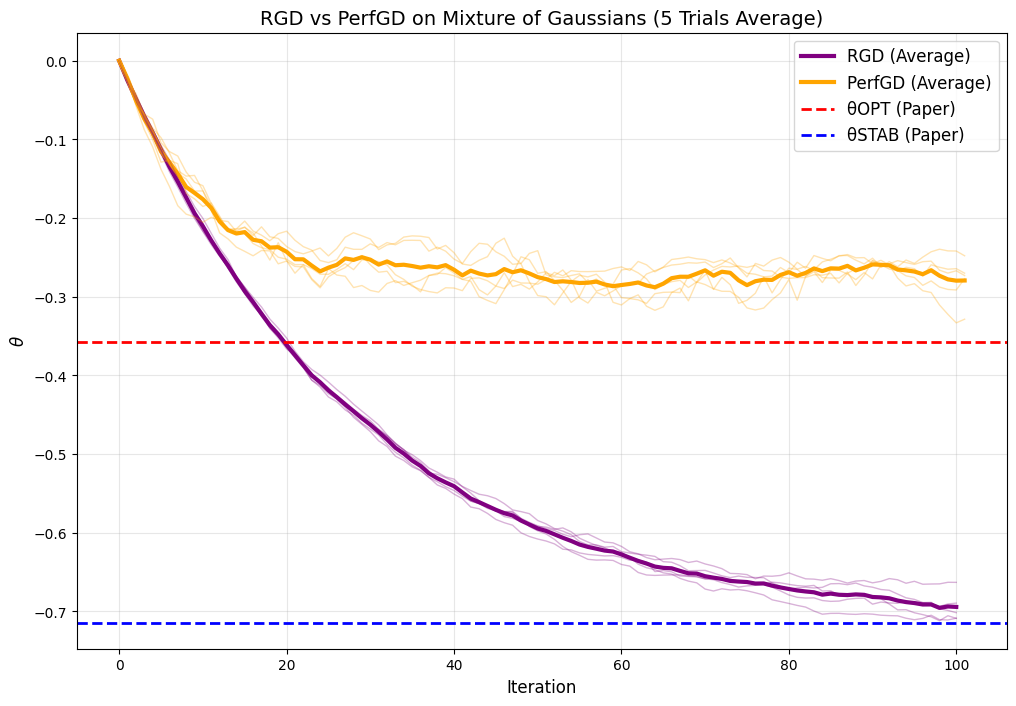


Summary Statistics (5 trials):
RGD final theta - Mean: -0.694330, Std: 0.017127
PerfGD final theta - Mean: -0.279360, Std: 0.026599
Theoretical θOPT: -0.357143
Theoretical θSTAB: -0.714286


In [5]:
run_experiment()